In [1]:
from typing import Dict, TypedDict, List
from langgraph.graph import StateGraph, START, END

c:\Users\ka448\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
class AgentState(TypedDict):
    player_name: str
    guesses: List[int]
    attempts: int
    lower_bound: int
    upper_bound: int
    guess: int
    main_guess :int
    hint: str

In [3]:
import random

def initialize_state(state: AgentState) -> AgentState:
    state['guesses'] = []
    state['attempts'] = 0
    state['lower_bound'] = 1
    state['upper_bound'] = 500
    state['guess'] = random.randint(1, 500)
    state['hint'] = ''
    print(f"Welcome {state['player_name']}! I'm thinking of a number between 1 and 20. Can you guess it?")
    print(f"The guess is {state['guess']}.")
    return state

def make_guess(state: AgentState) -> AgentState:
    state["attempts"] += 1
    if state['hint'] == "up":
        state['lower_bound'] = state['main_guess'] + 1
    if state["hint"] == "down":
        state["upper_bound"] = state["main_guess"] - 1
    state['main_guess'] = random.randint(state['lower_bound'], state['upper_bound'])
    state['guesses'].append(state["main_guess"])
    print(f"My guess is {state['main_guess']}.")
    print(f"Attempt {state['attempts']}: Guess_List = {state['guesses']}")
    return state


    
def hinting_function(state: AgentState) -> AgentState:
    if state["main_guess"] >state["guess"]:
        state["hint"] = "down"
    if state["main_guess"] < state["guess"]:
        state["hint"] = "up"
    print(f"My hint is {state['hint']}.")
    return state

def continuer_function(state:AgentState) -> AgentState:
    if state["main_guess"] == state["guess"]:
        print("Well done! You've guessed the number!")
        return "END"
    else:
        return "Continue"    

In [4]:
graph = StateGraph(AgentState)

In [5]:
graph.add_node("setup", initialize_state)
graph.add_node("guess", make_guess)
graph.add_node("hint_node", hinting_function)
graph.set_entry_point("setup")
graph.add_edge("setup", "guess")
graph.add_edge("guess", "hint_node")

graph.add_conditional_edges("hint_node", continuer_function, 
                            {"END": END,
                             "Continue": "guess"})
graph.set_finish_point("hint_node")

In [6]:
test = graph.compile()

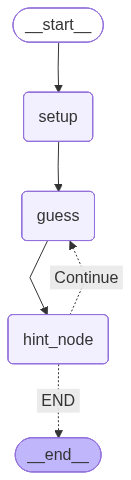

In [7]:
test

In [11]:
result = test.invoke({"player_name": "Alice"})

Welcome Alice! I'm thinking of a number between 1 and 20. Can you guess it?
The guess is 210.
My guess is 59.
Attempt 1: Guess_List = [59]
My hint is up.
My guess is 343.
Attempt 2: Guess_List = [59, 343]
My hint is down.
My guess is 218.
Attempt 3: Guess_List = [59, 343, 218]
My hint is down.
My guess is 66.
Attempt 4: Guess_List = [59, 343, 218, 66]
My hint is up.
My guess is 187.
Attempt 5: Guess_List = [59, 343, 218, 66, 187]
My hint is up.
My guess is 211.
Attempt 6: Guess_List = [59, 343, 218, 66, 187, 211]
My hint is down.
My guess is 198.
Attempt 7: Guess_List = [59, 343, 218, 66, 187, 211, 198]
My hint is up.
My guess is 208.
Attempt 8: Guess_List = [59, 343, 218, 66, 187, 211, 198, 208]
My hint is up.
My guess is 209.
Attempt 9: Guess_List = [59, 343, 218, 66, 187, 211, 198, 208, 209]
My hint is up.
My guess is 210.
Attempt 10: Guess_List = [59, 343, 218, 66, 187, 211, 198, 208, 209, 210]
My hint is up.
Well done! You've guessed the number!


In [9]:
result

{'player_name': 'Alice',
 'guesses': [234, 222, 223, 228, 226, 225, 224],
 'attempts': 7,
 'lower_bound': 224,
 'upper_bound': 224,
 'guess': 224,
 'main_guess': 224,
 'hint': 'down'}